# Tutorial 1 — Fitting and stacking galaxy-cluster weak-lensing profiles

**Audience.** Physics undergraduates / beginning grad students with calculus, basic probability, and some
Python. We build up MCMC, Bayesian fitting, and hierarchical inference from scratch — but be ready to work:
the later sections (hierarchical inference) are genuinely senior/first-year-grad level.

**What you will learn.**
1. How a Bayesian **posterior** is built from a **likelihood** and a **prior**, and how to *see* all three.
2. How fitting a cluster's weak-lensing profile is just **fitting a line in log–log space**.
3. The two ways to **stack** many noisy clusters — join-then-fit (JtF) and fit-then-join (FtJ) — and why one
   common form of FtJ is broken.
4. How **hierarchical Bayesian inference** (the "hyper-posterior") infers the *population* of clusters, and
   how per-cluster posteriors can be **recycled** by importance sampling.

We use a transparent toy so every posterior is also a Gaussian we can check by hand.

> Setup: `pip install "numpy<2" emcee colossus "matplotlib<3.9"`

In [1]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 12, "figure.figsize": (6, 4)})
np.random.seed(2807)
print("emcee", emcee.__version__, "| numpy", np.__version__)

emcee 3.1.6 | numpy 1.26.4


## 0. Bayes' theorem in one line

For parameters $\theta$ and data $d$:
$$\underbrace{p(\theta\mid d)}_{\text{posterior}}\;=\;\frac{\overbrace{p(d\mid\theta)}^{\text{likelihood }\mathcal L(\theta)}\;\overbrace{p(\theta)}^{\text{prior }\pi(\theta)}}{p(d)}\;\propto\;\mathcal L(\theta)\,\pi(\theta).$$
MCMC draws samples from the posterior; the **spread** of those samples is our **uncertainty**.

## 1. A cluster profile is a (declining) line in log–log space

A galaxy cluster's weak-lensing profile — the surface mass density $\Sigma(r)$ (or excess density
$\Delta\Sigma$) — is **high at small radius and falls off at large radius**. Near a power law, so in
**log–log space it is a straight line**:
$$\log_{10}\Sigma(r) \;=\; a \;-\; b\,\log_{10}\!\big(r/r_{\rm piv}\big).$$
- $a=\log_{10}\Sigma$ at the pivot radius — an **amplitude**, which scales with the cluster **mass**.
- $b$ = the (log) **slope**, which is steeper for more **concentrated** clusters.

So "fit the profile" $\equiv$ "fit a line" with parameters $\theta=(a,b)$. (This is the classic
*fitting-a-line-to-data* problem, here dressed as a cluster.)

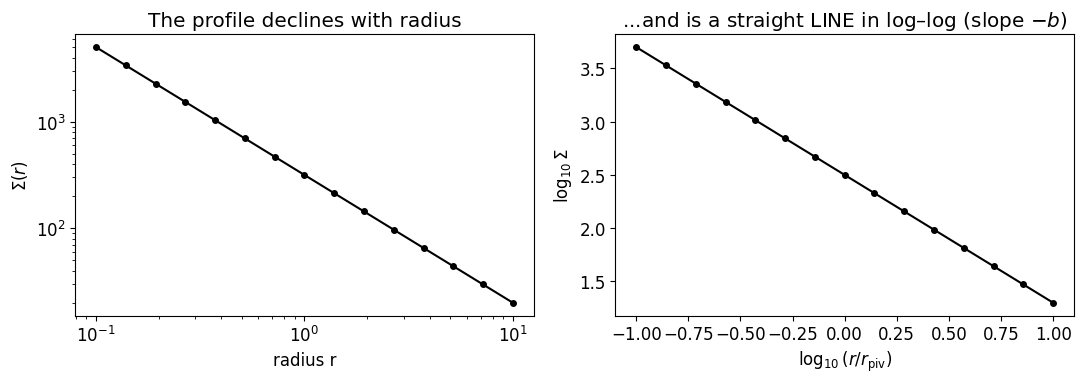

In [2]:
radii = np.logspace(-1, 1, 15)            # 15 radial bins, r = 0.1 .. 10 (e.g. arcmin or Mpc)
r_pivot = 1.0
log_r = np.log10(radii / r_pivot)         # the line's x-axis

def profile_model(theta):
    # log10 Sigma(r) = a - b log10(r/r_piv).  theta = (amplitude a, slope b).
    a, b = theta
    return a - b * log_r

a_true, b_true = 2.5, 1.2                  # one example cluster
log_sigma_true = profile_model((a_true, b_true))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(radii, 10**log_sigma_true, "k-o", ms=4)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("radius r"); ax[0].set_ylabel(r"$\Sigma(r)$")
ax[0].set_title("The profile declines with radius")
ax[1].plot(log_r, log_sigma_true, "k-o", ms=4)
ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[1].set_ylabel(r"$\log_{10}\Sigma$")
ax[1].set_title("...and is a straight LINE in log–log (slope $-b$)")
plt.tight_layout(); plt.show()

## 2. The data vector and the noise model

We **observe the profile in $N_r$ radial bins**, so the data is a **vector**
$d=(\log_{10}\Sigma^{\rm obs}_1,\dots,\log_{10}\Sigma^{\rm obs}_{N_r})$.

Each bin carries measurement noise. We model it as **Gaussian in $\log_{10}\Sigma$** with the same width
$\sigma$ (in "dex") in every bin, **independent** from bin to bin:
$$\log_{10}\Sigma^{\rm obs}_i \;=\; \big[a-b\log_{10}(r_i/r_{\rm piv})\big] \;+\; \varepsilon_i,
   \qquad \varepsilon_i\sim\mathcal N(0,\sigma^2).$$
Why this model? Gaussian-in-log is the same as **log-normal (multiplicative) noise in $\Sigma$** — which is
how weak-lensing profile errors are usually quoted (a "0.x dex" scatter). *Caveat for real data:* genuine
WL profiles have **correlated** radial bins (a full covariance matrix); we use a diagonal (per-bin
independent) covariance to keep the algebra transparent.

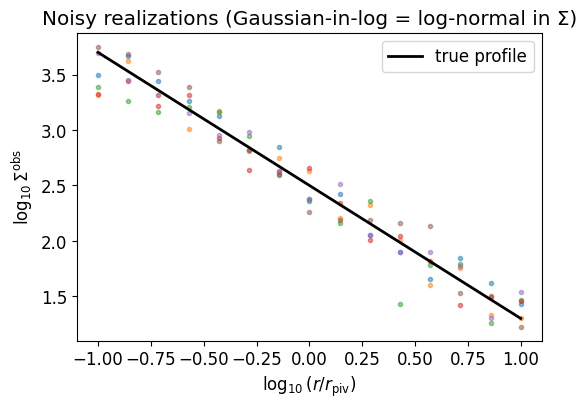

In [3]:
noise_dex = 0.15                                   # per-bin 1-sigma noise in log10 Sigma ("dex")
def observe(theta, sigma=noise_dex):
    # one noisy profile (a data VECTOR of length N_r)
    return profile_model(theta) + sigma * np.random.randn(len(radii))

plt.figure()
for _ in range(6):                                # several noisy realizations of the SAME cluster
    plt.plot(log_r, observe((a_true, b_true)), ".", alpha=0.5)
plt.plot(log_r, log_sigma_true, "k-", lw=2, label="true profile")
plt.xlabel(r"$\log_{10}(r/r_{\rm piv})$"); plt.ylabel(r"$\log_{10}\Sigma^{\rm obs}$")
plt.title("Noisy realizations (Gaussian-in-log = log-normal in Σ)"); plt.legend(); plt.show()

data_one = observe((a_true, b_true))               # the ONE cluster we will fit next

## 3. Inferring one cluster — and *seeing* the prior, likelihood, and posterior

**Likelihood** (independent Gaussian bins):
$$\ln\mathcal L(\theta)=-\tfrac12\sum_{i=1}^{N_r}\frac{\big(\log_{10}\Sigma^{\rm obs}_i-[a-b\log_{10}(r_i/r_{\rm piv})]\big)^2}{\sigma^2}.$$
**Prior**: flat (uniform) on a sensible box for $(a,b)$. **Posterior** $\propto$ likelihood $\times$ prior.

Because the model is linear and the noise Gaussian, we can draw the prior, likelihood, and posterior as
maps over the **parameter plane** $(a,b)$ — the literal picture of Bayes' theorem.

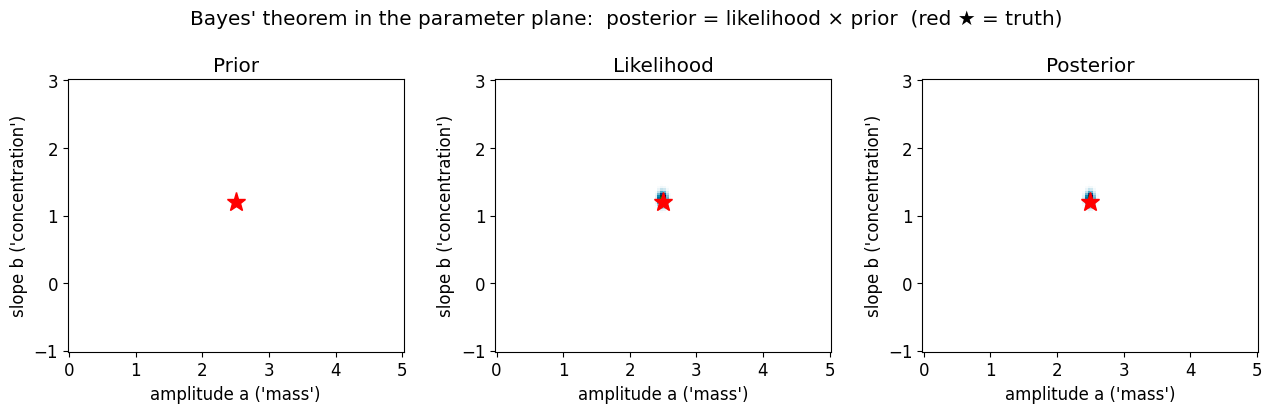

In [4]:
def log_likelihood(theta, d, sigma=noise_dex):
    resid = d - profile_model(theta)
    return -0.5 * np.sum(resid**2 / sigma**2)

A_LO, A_HI, B_LO, B_HI = 0.0, 5.0, -1.0, 3.0       # the flat-prior box for (a, b)
def log_prior(theta):
    a, b = theta
    return 0.0 if (A_LO < a < A_HI and B_LO < b < B_HI) else -np.inf

def log_posterior(theta, d, sigma=noise_dex):
    lp = log_prior(theta)
    return -np.inf if not np.isfinite(lp) else lp + log_likelihood(theta, d, sigma)

# Evaluate prior / likelihood / posterior on a grid over the (a,b) plane.
agrid = np.linspace(A_LO, A_HI, 120); bgrid = np.linspace(B_LO, B_HI, 120)
AA, BB = np.meshgrid(agrid, bgrid, indexing="ij")
model_cube = AA[..., None] - BB[..., None] * log_r          # predicted profile at every (a,b)
chi2 = np.sum((data_one - model_cube)**2 / noise_dex**2, axis=-1)
like_grid  = np.exp(-0.5 * (chi2 - chi2.min()))             # likelihood map
prior_grid = np.ones_like(like_grid)                        # flat prior map
post_grid  = like_grid * prior_grid                         # posterior = likelihood x prior

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for axi, grid, title in zip(ax, [prior_grid, like_grid, post_grid], ["Prior", "Likelihood", "Posterior"]):
    axi.pcolormesh(AA, BB, grid, shading="auto", cmap="ocean_r")
    axi.plot(a_true, b_true, "r*", ms=14)
    axi.set_xlabel("amplitude a ('mass')"); axi.set_ylabel("slope b ('concentration')"); axi.set_title(title)
fig.suptitle("Bayes' theorem in the parameter plane:  posterior = likelihood × prior  (red ★ = truth)")
plt.tight_layout(); plt.show()

With a **flat** prior the posterior is just the likelihood (an informative prior would multiply in and
reshape it). Another way to *see* prior vs posterior is in **data space**: draw profiles from the prior
(wild) versus from the posterior (a tight bundle through the data) — the "predictive" check.

   acceptance=0.71 | autocorr ~27 steps | ~2965 independent samples (want >> 1)


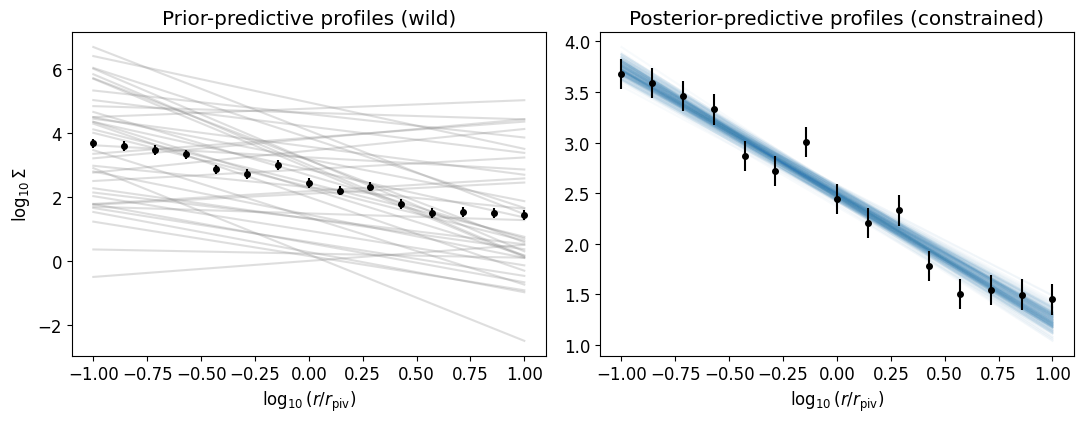

ONE cluster: posterior std on (a,b) = [0.039 0.063]  <- wide, from one noisy cluster


In [5]:
def run_mcmc(log_post, args, start, n_walkers=40, n_burn=500, n_steps=2000, verbose=True):
    # small reusable emcee wrapper -> flat samples (n_walkers*n_steps, n_dim)
    n_dim = len(start)
    p0 = start + 0.05 * np.random.randn(n_walkers, n_dim)
    s = emcee.EnsembleSampler(n_walkers, n_dim, log_post, args=args)
    state = s.run_mcmc(p0, n_burn, progress=False); s.reset(); s.run_mcmc(state, n_steps, progress=False)
    if verbose:
        # two cheap health checks: acceptance fraction, and autocorrelation time -> independent samples
        try: tau_ac = float(np.mean(s.get_autocorr_time(quiet=True)))
        except Exception: tau_ac = float("nan")
        ess = (n_walkers*n_steps/tau_ac) if tau_ac == tau_ac else float("nan")
        print("   acceptance=%.2f | autocorr ~%.0f steps | ~%.0f independent samples (want >> 1)"
              % (s.acceptance_fraction.mean(), tau_ac, ess))
    return s.get_chain(flat=True)

samples_one = run_mcmc(log_posterior, args=(data_one,), start=np.array([a_true, b_true]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
# prior-predictive: random (a,b) from the flat box -> profiles all over the place
for _ in range(40):
    th = [np.random.uniform(A_LO, A_HI), np.random.uniform(B_LO, B_HI)]
    ax[0].plot(log_r, profile_model(th), color="tab:gray", alpha=0.25)
ax[0].errorbar(log_r, data_one, yerr=noise_dex, fmt="ko", ms=4)
ax[0].set_title("Prior-predictive profiles (wild)"); ax[0].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[0].set_ylabel(r"$\log_{10}\Sigma$")
# posterior-predictive: profiles from posterior samples -> tight bundle through the data
for th in samples_one[np.random.randint(len(samples_one), size=200)]:
    ax[1].plot(log_r, profile_model(th), color="tab:blue", alpha=0.03)
ax[1].errorbar(log_r, data_one, yerr=noise_dex, fmt="ko", ms=4)
ax[1].set_title("Posterior-predictive profiles (constrained)"); ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$")
plt.tight_layout(); plt.show()
print("ONE cluster: posterior std on (a,b) =", samples_one.std(axis=0).round(3), " <- wide, from one noisy cluster")

**MCMC health checks.** Each `run_mcmc` prints two diagnostics: the **acceptance fraction** (should sit
well away from 0 and 1) and the **autocorrelation time** $\tau_{\rm ac}$ — the number of steps between
effectively *independent* samples. You want `n_steps` $\gg\tau_{\rm ac}$ (many independent samples); if not,
increase `n_steps`. Never trust a posterior width from an unconverged chain.

## 4. A *population* of clusters (the generative model)

Real clusters are not identical: each has its own true $(a_j,b_j)$, drawn from a **population**. We model the
population as a Gaussian with **hyper-parameters** = the population mean $\boldsymbol\mu_{\rm pop}$ and the
**intrinsic scatter** $\mathbf s_{\rm pop}$:
$$\theta_j=(a_j,b_j)\sim\mathcal N\!\big(\boldsymbol\mu_{\rm pop},\,\mathrm{diag}(\mathbf s_{\rm pop}^2)\big),\qquad d_j=\text{(noisy profile of cluster }j).$$
We **fix the true hyper-parameters** below (this is our ground truth); the goal of Section 8 will be to
recover them.

TRUE hyper-parameters:  population mean = [2.5 1.2]   intrinsic scatter = [0.25 0.3 ]


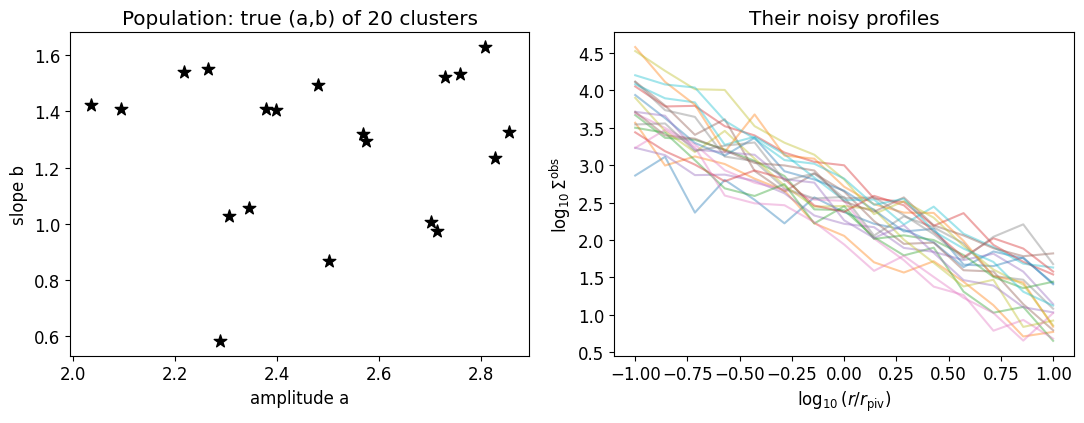

In [6]:
n_clusters = 20
mu_pop = np.array([2.50, 1.20])      # TRUE population mean of (amplitude, slope)
s_pop  = np.array([0.25, 0.30])      # TRUE intrinsic scatter (cluster-to-cluster)
print("TRUE hyper-parameters:  population mean =", mu_pop, "  intrinsic scatter =", s_pop)

theta_true = mu_pop + s_pop * np.random.randn(n_clusters, 2)         # each cluster's true (a,b)
profiles   = np.array([profile_model(theta_true[j]) + noise_dex*np.random.randn(len(radii))
                       for j in range(n_clusters)])                  # their noisy profiles

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].scatter(theta_true[:, 0], theta_true[:, 1], c="k", marker="*", s=90)
ax[0].set_xlabel("amplitude a"); ax[0].set_ylabel("slope b"); ax[0].set_title("Population: true (a,b) of %d clusters" % n_clusters)
for p in profiles:
    ax[1].plot(log_r, p, alpha=0.4)
ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[1].set_ylabel(r"$\log_{10}\Sigma^{\rm obs}$"); ax[1].set_title("Their noisy profiles")
plt.tight_layout(); plt.show()

## 5. Stacking: two strategies (and the bug)

To beat down the noise we combine the $N_c$ clusters. Three likelihoods (they all share one $\theta$):

**Join-then-fit (JtF)** — average the data first, then fit once. Use the **median** profile $\tilde d$; the
median's error is $\tilde\sigma=\sqrt{\pi/2}\,\sigma/\sqrt{N_c}$ (the asymptotic standard error of the median
of $N_c$ Gaussians; we also approximate its distribution as Gaussian):
$$\ln\mathcal L_{\rm JtF}=-\tfrac12\sum_i (\tilde d_i-\text{model}_i)^2/\tilde\sigma^2.$$
**Fit-then-join (FtJ), as printed in the paper** — compares the model to every cluster but **divides by $N_c$**:
$$\ln\mathcal L_{\rm FtJ}=-\frac{1}{2N_c}\sum_j\sum_i (d_{i,j}-\text{model}_i)^2/\sigma^2.$$
**Correct joint** — independent clusters **multiply** their likelihoods, so the logs **add** (no $1/N_c$):
$$\ln\mathcal L_{\rm joint}=\sum_j\ln\mathcal L_j=-\tfrac12\sum_j\sum_i (d_{i,j}-\text{model}_i)^2/\sigma^2.$$

In [7]:
median_profile = np.median(profiles, axis=0)
sigma_tilde_sq = (np.pi/2) * noise_dex**2 / n_clusters
def with_prior(loglike):
    return lambda th: loglike(th) if np.isfinite(log_prior(th)) else -np.inf

ll_JtF   = lambda th: -0.5 * np.sum((median_profile - profile_model(th))**2 / sigma_tilde_sq)
ll_FtJ   = lambda th: -(1/(2*n_clusters)) * np.sum((profiles - profile_model(th))**2 / noise_dex**2)
ll_joint = lambda th: -0.5 * np.sum((profiles - profile_model(th))**2 / noise_dex**2)

samp_JtF   = run_mcmc(with_prior(ll_JtF),   args=(), start=mu_pop)
samp_FtJ   = run_mcmc(with_prior(ll_FtJ),   args=(), start=mu_pop)
samp_joint = run_mcmc(with_prior(ll_joint), args=(), start=mu_pop)
w = lambda s: s[:, 0].std()      # uncertainty on amplitude a
print("\nposterior width on amplitude a:")
print("  JtF=%.4f   FtJ(paper)=%.4f   correct joint=%.4f" % (w(samp_JtF), w(samp_FtJ), w(samp_joint)))
print("  FtJ/JtF = %.2f (sqrt(2Nc/pi)=%.2f) | FtJ/joint = %.2f (sqrt(Nc)=%.2f)"
      % (w(samp_FtJ)/w(samp_JtF), np.sqrt(2*n_clusters/np.pi), w(samp_FtJ)/w(samp_joint), np.sqrt(n_clusters)))

   acceptance=0.71 | autocorr ~29 steps | ~2792 independent samples (want >> 1)


   acceptance=0.71 | autocorr ~29 steps | ~2781 independent samples (want >> 1)


   acceptance=0.71 | autocorr ~28 steps | ~2819 independent samples (want >> 1)

posterior width on amplitude a:
  JtF=0.0111   FtJ(paper)=0.0387   correct joint=0.0088
  FtJ/JtF = 3.48 (sqrt(2Nc/pi)=3.57) | FtJ/joint = 4.38 (sqrt(Nc)=4.47)


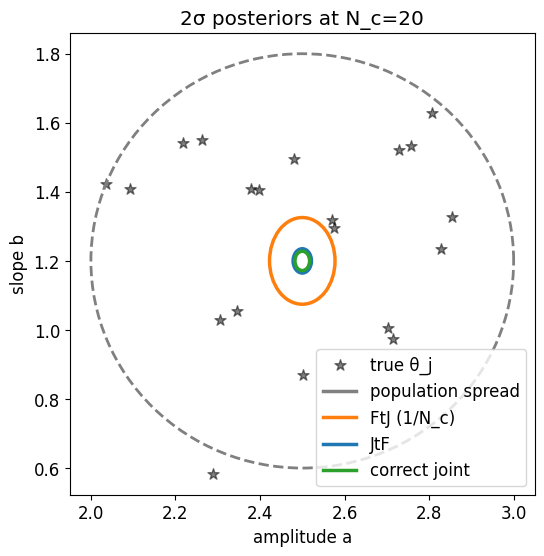

In [8]:
from matplotlib.patches import Ellipse
def cov_ellipse(ax, c, cov, n=2, **kw):
    v, V = np.linalg.eigh(cov); o = v.argsort()[::-1]; v, V = v[o], V[:, o]
    ang = np.degrees(np.arctan2(V[1, 0], V[0, 0])); ax.add_patch(Ellipse(c, *(2*n*np.sqrt(v)), angle=ang, fill=False, **kw))
XtX_inv = np.linalg.inv((np.column_stack([np.ones_like(log_r), -log_r])).T @ np.column_stack([np.ones_like(log_r), -log_r]))
fig, ax = plt.subplots(figsize=(6, 6)); c = mu_pop
ax.scatter(theta_true[:, 0], theta_true[:, 1], marker="*", s=70, color="k", alpha=0.5, label="true θ_j")
cov_ellipse(ax, c, np.diag(s_pop**2), color="gray", lw=2, ls="--"); cov_ellipse(ax, c, noise_dex**2*XtX_inv, color="tab:orange", lw=2.5)
cov_ellipse(ax, c, sigma_tilde_sq*XtX_inv, color="tab:blue", lw=2.5); cov_ellipse(ax, c, noise_dex**2/n_clusters*XtX_inv, color="tab:green", lw=2.5)
for lab, col in [("population spread", "gray"), ("FtJ (1/N_c)", "tab:orange"), ("JtF", "tab:blue"), ("correct joint", "tab:green")]:
    ax.plot([], [], color=col, lw=2.5, label=lab)
ax.set_xlabel("amplitude a"); ax.set_ylabel("slope b"); ax.set_title("2σ posteriors at N_c=20"); ax.legend(); plt.show()

*Reading a covariance ellipse:* its **size** is the uncertainty (the $2\sigma$ ellipse $\approx$ 95%
region), its **tilt** is the correlation between the two parameters, and its principal axes are the
eigenvectors of the covariance matrix. Notice the orange **FtJ** ellipse is nearly as large as the gray
population spread — that is the bug, not a feature.

## 6. The diagnostic: does adding clusters help?

Stacking *should* tighten the answer as $1/\sqrt{N_c}$. Sweep $N_c$ using the exact Gaussian widths
(already confirmed to match the MCMC above).

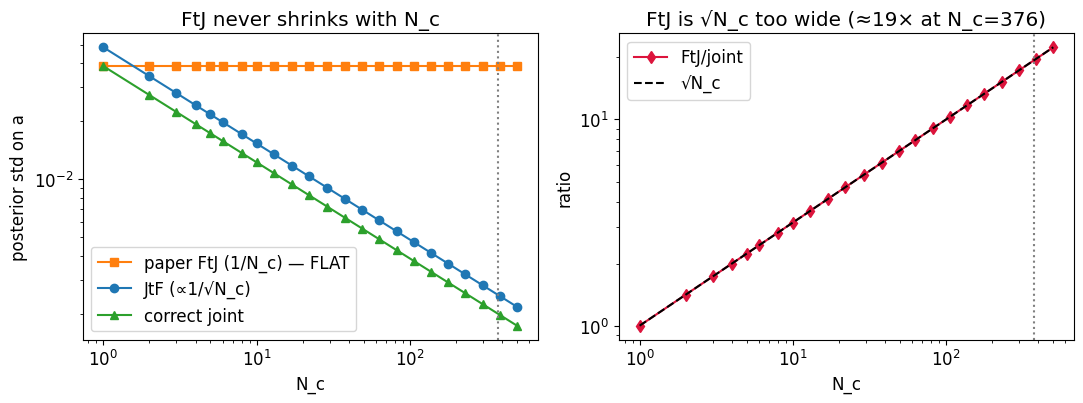

In [9]:
w0 = np.sqrt(XtX_inv[0, 0]); Nc = np.unique(np.round(np.logspace(0, 2.7, 25)).astype(int))
W_JtF = np.sqrt(np.pi/2)*noise_dex*w0/np.sqrt(Nc); W_jnt = noise_dex*w0/np.sqrt(Nc); W_FtJ = noise_dex*w0*np.ones_like(Nc, float)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].loglog(Nc, W_FtJ, "s-", color="tab:orange", label="paper FtJ (1/N_c) — FLAT"); ax[0].loglog(Nc, W_JtF, "o-", color="tab:blue", label="JtF (∝1/√N_c)")
ax[0].loglog(Nc, W_jnt, "^-", color="tab:green", label="correct joint"); ax[0].axvline(376, color="gray", ls=":")
ax[0].set_xlabel("N_c"); ax[0].set_ylabel("posterior std on a"); ax[0].set_title("FtJ never shrinks with N_c"); ax[0].legend()
ax[1].loglog(Nc, W_FtJ/W_jnt, "d-", color="crimson", label="FtJ/joint"); ax[1].loglog(Nc, np.sqrt(Nc), "k--", label="√N_c"); ax[1].axvline(376, color="gray", ls=":")
ax[1].set_xlabel("N_c"); ax[1].set_ylabel("ratio"); ax[1].set_title("FtJ is √N_c too wide (≈19× at N_c=376)"); ax[1].legend(); plt.tight_layout(); plt.show()

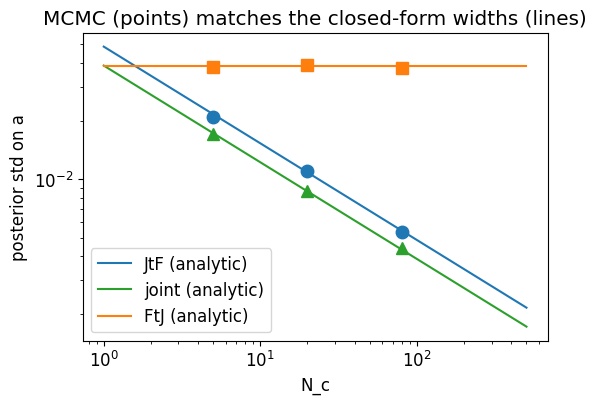

MCMC widths land on the analytic curves -> the instant N_c-sweep is trustworthy.


In [10]:
# VALIDATION: overlay the MEASURED MCMC widths (at a few N_c) on the analytic curves above.
meas = {"JtF": [], "joint": [], "FtJ": []}; Nc_test = [5, 20, 80]
for nc in Nc_test:
    th = mu_pop + s_pop*np.random.randn(nc, 2)
    pr = np.array([profile_model(th[j]) + noise_dex*np.random.randn(len(radii)) for j in range(nc)])
    mdp = np.median(pr, axis=0); st2 = (np.pi/2)*noise_dex**2/nc
    fj = run_mcmc(with_prior(lambda t, mdp=mdp, st2=st2: -0.5*np.sum((mdp-profile_model(t))**2/st2)), (), mu_pop, n_burn=200, n_steps=600, verbose=False)
    jn = run_mcmc(with_prior(lambda t, pr=pr: -0.5*np.sum((pr-profile_model(t))**2/noise_dex**2)), (), mu_pop, n_burn=200, n_steps=600, verbose=False)
    ft = run_mcmc(with_prior(lambda t, pr=pr, nc=nc: -(1/(2*nc))*np.sum((pr-profile_model(t))**2/noise_dex**2)), (), mu_pop, n_burn=200, n_steps=600, verbose=False)
    meas["JtF"].append(fj[:, 0].std()); meas["joint"].append(jn[:, 0].std()); meas["FtJ"].append(ft[:, 0].std())
plt.figure()
plt.loglog(Nc, W_JtF, "-", color="tab:blue", label="JtF (analytic)");  plt.loglog(Nc_test, meas["JtF"], "o", ms=9, color="tab:blue")
plt.loglog(Nc, W_jnt, "-", color="tab:green", label="joint (analytic)"); plt.loglog(Nc_test, meas["joint"], "^", ms=9, color="tab:green")
plt.loglog(Nc, W_FtJ, "-", color="tab:orange", label="FtJ (analytic)");  plt.loglog(Nc_test, meas["FtJ"], "s", ms=9, color="tab:orange")
plt.xlabel("N_c"); plt.ylabel("posterior std on a"); plt.title("MCMC (points) matches the closed-form widths (lines)"); plt.legend(); plt.show()
print("MCMC widths land on the analytic curves -> the instant N_c-sweep is trustworthy.")

**The bug.** The $1/N_c$ turns the *sum* of per-cluster information into an *average* — the precision of a
**single** cluster, independent of $N_c$. JtF and the correct joint instead tighten as $1/\sqrt{N_c}$.
**Fix:** drop the $1/N_c$ (use a sum).

## 7. The real NFW profile *(optional — needs Colossus)*

Our toy is a power law; a real cluster is an **NFW** halo. Below we plot a real NFW surface-density profile
(it also declines) and fit it with JtF vs FtJ, showing the **posterior contours** (not just numbers).
*(For simplicity each cluster's $M$ and $c$ are drawn independently; real halos have a mild
anti-correlation — the mass–concentration relation.)*

The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 18;
tau: [26.32989931 25.41489634]


   acceptance=0.72 | autocorr ~26 steps | ~1391 independent samples (want >> 1)


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 18;
tau: [23.28544855 23.34953413]


   acceptance=0.72 | autocorr ~23 steps | ~1544 independent samples (want >> 1)


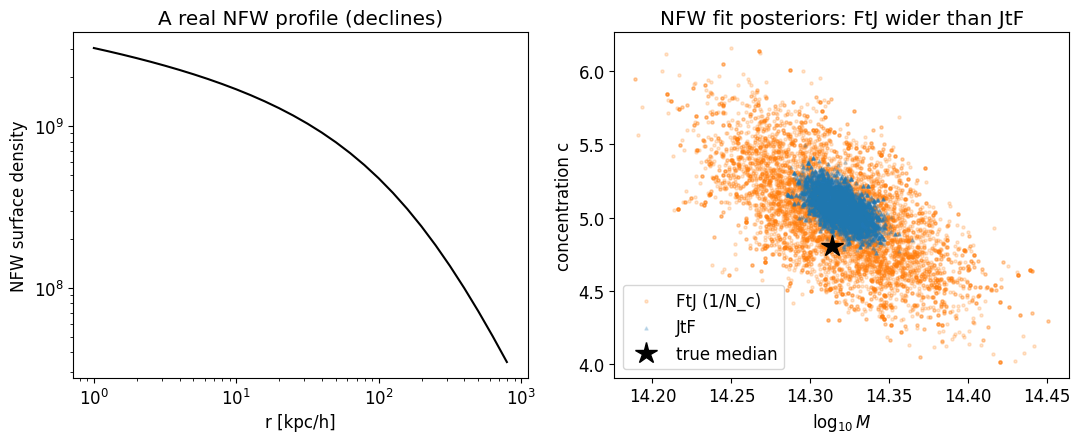

NFW: FtJ/JtF width(log10M) = 3.56


In [11]:
try:
    from colossus.cosmology import cosmology; from colossus.halo import profile_nfw
    cosmology.setCosmology("planck18"); nfw_r = 10**np.arange(0, 3, 0.1)
    def nfw_logSigma(theta):                         # theta = (log10 mass, concentration)
        h = profile_nfw.NFWProfile(M=10**theta[0], c=theta[1], z=0.0, mdef="vir")
        return np.log10(h.surfaceDensity(nfw_r))
    th0 = np.array([14.3, 5.0]); dex = 0.10
    # population of NFW clusters + noisy profiles
    Nc2 = 20; m = 14.3 + 0.10*np.random.randn(Nc2); cc = 5.0 + 0.7*np.random.randn(Nc2)
    P = np.array([nfw_logSigma([m[j], cc[j]]) + dex*np.random.randn(len(nfw_r)) for j in range(Nc2)])
    med = np.median(P, axis=0); st2 = (np.pi/2)*dex**2/Nc2
    inb = lambda t: 13.5 < t[0] < 15 and 1 < t[1] < 12
    lj = lambda t: (-0.5*np.sum((nfw_logSigma(t)-med)**2/st2)) if inb(t) else -np.inf
    lf = lambda t: (-(1/(2*Nc2))*np.sum((nfw_logSigma(t)[None]-P)**2/dex**2)) if inb(t) else -np.inf
    s_j = run_mcmc(lj, args=(), start=th0, n_walkers=40, n_burn=300, n_steps=900)
    s_f = run_mcmc(lf, args=(), start=th0, n_walkers=40, n_burn=300, n_steps=900)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
    ax[0].plot(nfw_r, 10**nfw_logSigma(th0), "k-"); ax[0].set_xscale("log"); ax[0].set_yscale("log")
    ax[0].set_xlabel("r [kpc/h]"); ax[0].set_ylabel("NFW surface density"); ax[0].set_title("A real NFW profile (declines)")
    ax[1].scatter(s_f[::5, 0], s_f[::5, 1], s=5, alpha=0.2, marker="o", color="tab:orange", label="FtJ (1/N_c)")
    ax[1].scatter(s_j[::5, 0], s_j[::5, 1], s=5, alpha=0.2, marker="^", color="tab:blue", label="JtF")
    ax[1].plot(np.median(m), np.median(cc), "k*", ms=16, label="true median")
    ax[1].set_xlabel(r"$\log_{10} M$"); ax[1].set_ylabel("concentration c"); ax[1].set_title("NFW fit posteriors: FtJ wider than JtF"); ax[1].legend()
    plt.tight_layout(); plt.show()
    print("NFW: FtJ/JtF width(log10M) = %.2f" % (s_f[:, 0].std()/s_j[:, 0].std()))
except Exception as e:
    print("Colossus not available; skipping NFW:", e)

## 8. Hierarchical Bayesian inference: the **hyper-posterior**

JtF/FtJ all estimate one shared $\theta$ — the population *mean*. To get the population itself (its mean
**and** its intrinsic scatter) we go **hierarchical**. Following the gravitational-wave population literature
(Thrane & Talbot 2019), the population parameters are **hyper-parameters** $\Lambda$, and we want the
**hyper-posterior**
$$p(\Lambda\mid\{d_j\})\ \propto\ \pi(\Lambda)\prod_j\int p(d_j\mid\theta_j)\,p(\theta_j\mid\Lambda)\,d\theta_j .$$
**Recycling (importance sampling).** With stored per-cluster posterior samples
$\theta_j^{(s)}\sim p(\theta_j\mid d_j)\propto p(d_j\mid\theta_j)\pi_0(\theta_j)$, the integral becomes a sum
over those samples, reweighted by population-prior / sampling-prior:
$$\int p(d_j\mid\theta)p(\theta\mid\Lambda)d\theta\ \approx\ \frac{\mathcal Z_j}{S}\sum_s\frac{p(\theta_j^{(s)}\mid\Lambda)}{\pi_0(\theta_j^{(s)})}.$$
We demonstrate it on the **amplitude** $a$ (the mass proxy): hyper-parameters $\Lambda=(\mu_a,\tau_a)$ =
population mean and intrinsic scatter. The per-cluster posteriors on $a$ are the ones we just fit. *(Implementation note: we sample $\log\tau_a$ so
$\tau_a>0$ automatically; the `+lt` term in the code is the change-of-variables **Jacobian** — equivalent to
a flat prior on $\tau_a$ itself.)*

   acceptance=0.70 | autocorr ~31 steps | ~1173 independent samples (want >> 1)

HYPER-POSTERIOR on the population of amplitudes:
  truth :  mu_a=2.500  tau_a=0.250
  recycle: mu_a=2.474±0.062  tau_a=0.266±0.050


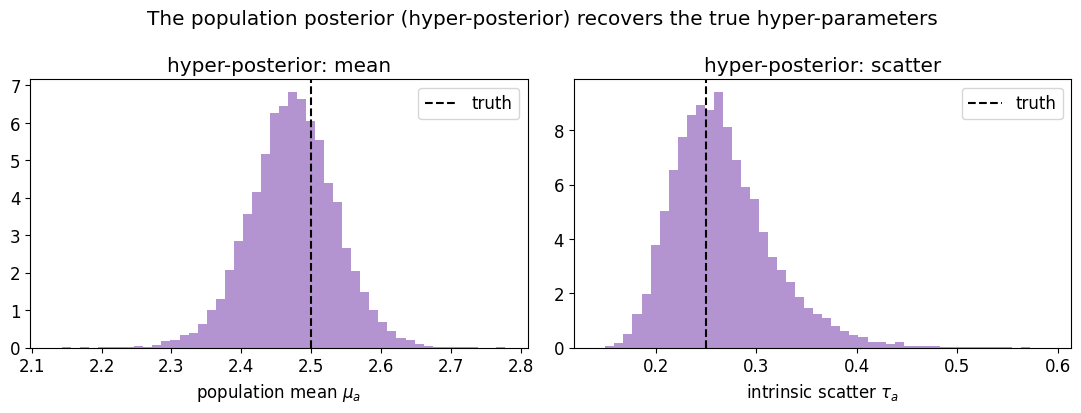

In [12]:
# per-cluster posteriors on the amplitude a (exact Gaussian: center = LS fit, width from XtX_inv)
Xmat = np.column_stack([np.ones_like(log_r), -log_r]); cov_one = noise_dex**2 * np.linalg.inv(Xmat.T @ Xmat)
a_hat = np.array([np.linalg.solve(Xmat.T @ Xmat, Xmat.T @ p)[0] for p in profiles])  # per-cluster best-fit a
sig_a = np.sqrt(cov_one[0, 0])                                                        # per-cluster a uncertainty
Spc = 3000
a_samples = a_hat[:, None] + sig_a*np.random.randn(n_clusters, Spc)   # recycled per-cluster posterior samples

mu_a_true, tau_a_true = mu_pop[0], s_pop[0]
# (B) recycle: hyper-loglike(mu,tau) = sum_j log mean_s N(a_j^s | mu, tau)   (flat pi_0 cancels)
def hyper_logpost(p):
    mu, lt = p; tau = np.exp(lt)
    if tau > 3: return -np.inf
    tot = sum(np.log(np.mean(np.exp(-0.5*((a_samples[j]-mu)/tau)**2)/tau)+1e-300) for j in range(n_clusters))
    return tot + lt    # +lt = Jacobian for sampling in log(tau)  (=> flat prior on tau itself)
hyper_chain = run_mcmc(hyper_logpost, args=(), start=np.array([mu_a_true, np.log(tau_a_true)]),
                       n_walkers=12, n_burn=1500, n_steps=3000)
mu_hat, tau_hat = hyper_chain[:, 0], np.exp(hyper_chain[:, 1])
print("\nHYPER-POSTERIOR on the population of amplitudes:")
print("  truth :  mu_a=%.3f  tau_a=%.3f" % (mu_a_true, tau_a_true))
print("  recycle: mu_a=%.3f±%.3f  tau_a=%.3f±%.3f" % (mu_hat.mean(), mu_hat.std(), tau_hat.mean(), tau_hat.std()))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].hist(mu_hat, 50, density=True, color="tab:purple", alpha=0.7); ax[0].axvline(mu_a_true, color="k", ls="--", label="truth")
ax[0].set_xlabel(r"population mean $\mu_a$"); ax[0].set_title("hyper-posterior: mean"); ax[0].legend()
ax[1].hist(tau_hat, 50, density=True, color="tab:purple", alpha=0.7); ax[1].axvline(tau_a_true, color="k", ls="--", label="truth")
ax[1].set_xlabel(r"intrinsic scatter $\tau_a$"); ax[1].set_title("hyper-posterior: scatter"); ax[1].legend()
plt.suptitle("The population posterior (hyper-posterior) recovers the true hyper-parameters"); plt.tight_layout(); plt.show()

**Read-off.** The hyper-posterior is a distribution over the *population* parameters (mean and intrinsic
scatter), and it brackets the truth (dashed lines). Crucially we never re-fit a cluster — we **recycled** the
stored per-cluster posteriors. This is the engine of cluster mass calibration (Tutorial 2 turns the
population model into a richness–mass relation).

> **One idea, three faces — shrinkage.** Every failure mode in these tutorials is the *same* mistake:
> not pulling noisy individual estimates toward the population.
> - **Naive stacking** (the FtJ $1/N_c$) *averages* per-cluster information instead of accumulating it, so it
>   never tightens with $N_c$.
> - **Regression dilution / Eddington bias** (Tutorial 2) lets measurement noise in the mass flatten the
>   fitted slope, because nothing pulls up-scattered masses back down.
> - **Correct hierarchical reuse** multiplies each per-cluster posterior by the population prior
>   $p(\theta\mid\Lambda)$ (the weight $p(x)/\pi_0$). *That factor **is** the shrinkage — and it fixes both.*

## 9. Summary
1. Fitting a cluster profile = **fitting a line** in log–log; the posterior is built as **likelihood × prior**
   and is best understood by *seeing* it (the triptych) and via **predictive** profiles.
2. Stacking should tighten as $1/\sqrt{N_c}$; the paper's FtJ `1/N_c` makes it **flat in $N_c$** (√N_c too
   wide). **Fix: use a sum.**
3. The *population* (mean + intrinsic scatter) is the **hyper-posterior**, obtained by **recycling**
   per-cluster posteriors via importance sampling.

## 10. Try it yourself
- **§6:** change the FtJ `1/N_c` to `1/sqrt(N_c)` — does the width-vs-$N_c$ line still go flat? Predict first.
- **§5:** set `n_clusters = 100`. Predict `FtJ/joint` before running, then check it ≈ √100.
- **§2/§3:** raise `noise_dex` to 0.4 — watch the posterior-predictive bundle widen and the triptych blur.
- **§8:** shrink `n_clusters` to 5 — does the hyper-posterior still bracket the truth? Why does $\tau_a$ get
  much less certain?